# Maternal and Reproductive Health: A Global Data-Driven Summary

**Student:** Husain Malwat (21110117), Rohit Raj(21110179), Balgopal
Moharana(21110040) <br> **Date:** 23rd April 2025

## 1. Introduction

Maternal and reproductive health is a critical component of global
public health. Indicators such as Maternal Mortality Ratio (MMR),
Antenatal Care (ANC) coverage, Skilled Birth Attendance (SBA), and
anaemia prevalence provide vital insights into the well-being of women
and newborns, reflecting the strength and equity of health systems
worldwide. Access to quality care during pregnancy and childbirth
significantly reduces maternal and neonatal mortality and morbidity.

This report analyzes several datasets provided by the World Health
Organization (WHO) focusing on key maternal and reproductive health
indicators across different countries and regions. The primary goals
are:

1.  To provide an overview of the data and explore the global
    distribution of these indicators.
2.  To investigate potential relationships between different health
    indicators (e.g., care coverage vs. mortality outcomes, anaemia
    vs. mortality).
3.  To examine regional disparities in maternal and reproductive health
    outcomes and care access.
4.  To formulate and test hypotheses regarding these relationships and
    disparities using data visualization and basic statistical analysis.

**Data Sources:** Datasets derived from the World Health Organization
(WHO) Global Health Observatory (GHO) data repository, focusing on: \*
Maternal Mortality Ratio (MMR) \* Skilled Birth Attendance (SBA) \*
Antenatal Care Coverage (ANC4+ visits) \* Anaemia Prevalence (Pregnant
Women, Non-Pregnant Women, Overall)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
warnings.filterwarnings('ignore')

## 2. Data Loading and Initial Exploration

We begin by loading the provided datasets into pandas DataFrames. Each
file represents a different aspect of maternal and reproductive health.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

In [ ]:
import shutil
source_folder = '/content/drive/MyDrive/ds_writ/dataset'
destination_folder = '/content/dataset'

try:
  shutil.copytree(source_folder, destination_folder)
  print(f"Folder '{source_folder}' copied to '{destination_folder}' successfully.")
except FileExistsError:
  print(f"Folder '{destination_folder}' already exists. Please choose a different destination.")
except Exception as e:
  print(f"An error occurred during the copy process: {e}")


Folder '/content/dataset' already exists. Please choose a different destination.

In [ ]:
%cd ./dataset

[Errno 2] No such file or directory: './dataset'
/content/dataset

In [ ]:
try:
    df_mmr = pd.read_csv('mmr_data_cleaned.csv')
    df_sba = pd.read_csv('skilled_birth_attendance_cleaned.csv')
    df_anc = pd.read_csv('antenatal_care_coverage_cleaned.csv')
    df_anaemia_preg = pd.read_csv('anaemia_indicators_preg.csv')
    df_anaemia_nonpreg = pd.read_csv('anaemia_indicators_nonpreg_cleaned.csv')
    df_anaemia_overall_raw = pd.read_csv('anaemia_indicators_overall.csv')

    print("Datasets loaded successfully.")

except FileNotFoundError as e:
    print(f"Error loading datasets: {e}")
    print("Please ensure all CSV files are in the correct directory.")
    df_mmr, df_sba, df_anc, df_anaemia_preg, df_anaemia_nonpreg, df_anaemia_overall_raw = [pd.DataFrame()]*6

Datasets loaded successfully.

In [ ]:
# Load all datasets
datasets = {
    "Skilled Birth Attendance": pd.read_csv("skilled_birth_attendance_cleaned.csv"),
    "Antenatal Care": pd.read_csv("antenatal_care_coverage_cleaned.csv"),
    "Facility Births": pd.read_csv("health_facility_cleaned.csv"),
    "MMR": pd.read_csv("mmr_data_cleaned.csv"),
    "Caesarean": pd.read_csv("caesearean.csv", encoding='latin1'),
    "Anaemia Pregnant": pd.read_csv("anaemia_indicators_preg.csv"),
    "Anaemia NonPreg": pd.read_csv("anaemia_indicators_nonpreg_cleaned.csv"),
    "Anaemia Overall": pd.read_csv("anaemia_indicators_overall.csv"),
    # "Hemoglobin Preg": pd.read_csv("mean_haemog_preg.csv"),
    # "Hemoglobin NonPreg": pd.read_csv("mean_haemog_nonpreg.csv"),
    "Family Planning": pd.read_csv("family_planning.csv")
}

# Normalize column names
for name, df in datasets.items():
    df.columns = df.columns.str.strip().str.replace(" ", "_").str.replace("__", "_")

# Preview structure
for name, df in datasets.items():
    print(f"{name} => Shape: {df.shape}, Columns: {df.columns.tolist()}")

Skilled Birth Attendance => Shape: (2381, 4), Columns: ['Country', 'Year', 'Skilled_Birth_Attendance', 'Region']
Antenatal Care => Shape: (3468, 4), Columns: ['Country', 'Year', 'Antenatal_Care_Coverage', 'Region']
Facility Births => Shape: (3840, 4), Columns: ['Country', 'Year', 'Facility_Births', 'Region']
MMR => Shape: (15210, 4), Columns: ['Country', 'Year', 'MMR', 'Region']
Caesarean => Shape: (172, 4), Columns: ['Region', 'Country', 'Year', 'Caesarean_Rate']
Anaemia Pregnant => Shape: (3840, 4), Columns: ['Region', 'Country', 'Year', 'Anaemia_Prevalence_Pregnant']
Anaemia NonPreg => Shape: (3840, 4), Columns: ['Country', 'Year', 'Anaemia_Prevalence_NonPregnant', 'Region']
Anaemia Overall => Shape: (15600, 5), Columns: ['Region', 'Country', 'Year', 'Severity', 'Anaemia_Prevalence_overall']
Family Planning => Shape: (443, 4), Columns: ['Region', 'Country', 'Year', 'Modern_Methods']

### Basic Cleaning & Merging

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets
from scipy.stats import ttest_ind, pearsonr, spearmanr
import warnings
from functools import reduce

warnings.filterwarnings('ignore')
%matplotlib inline

dfs_to_merge = []
for name, df in datasets.items():
    if 'Country' in df.columns and 'Year' in df.columns:
        df['Year'] = df['Year'].astype(str)
        if 'Region' in df.columns:
            df.rename(columns={'Region': f"Region_{name.replace(' ', '_')}"}, inplace=True)
        dfs_to_merge.append(df)

merged_df = reduce(lambda left, right: pd.merge(left, right, on=['Country', 'Year'], how='outer'), dfs_to_merge)

region_cols = [col for col in merged_df.columns if col.startswith("Region_")]
if region_cols:
    merged_df['Region'] = merged_df[region_cols[0]]
    for col in region_cols[1:]:
        merged_df['Region'] = merged_df['Region'].combine_first(merged_df[col])
    merged_df.drop(columns=region_cols, inplace=True)


merged_df.drop_duplicates(inplace=True)
merged_df.sort_values(by=["Country", "Year"], inplace=True)

if 'Region_x' in merged_df.columns:
    merged_df['Region'] = merged_df['Region_x'].combine_first(merged_df.get('Region_y'))
    merged_df.drop(columns=[c for c in merged_df.columns if c.startswith("Region_")], inplace=True)

merged_df.head()

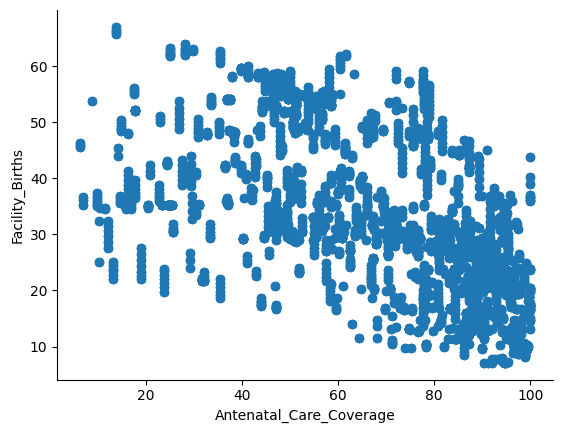

In [ ]:
# @title Antenatal_Care_Coverage vs Facility_Births

from matplotlib import pyplot as plt
merged_df.plot(kind='scatter', x='Antenatal_Care_Coverage', y='Facility_Births', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

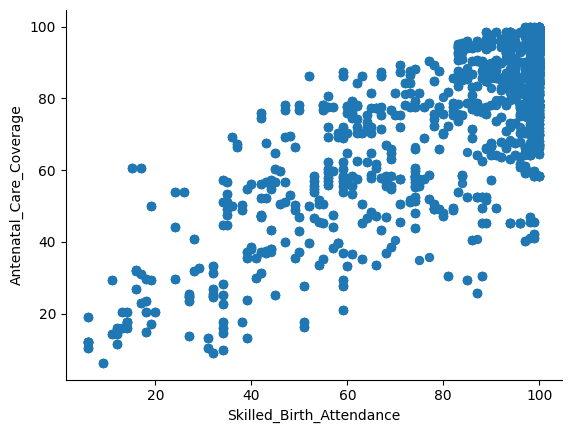

In [ ]:
# @title Skilled_Birth_Attendance vs Antenatal_Care_Coverage

from matplotlib import pyplot as plt
merged_df.plot(kind='scatter', x='Skilled_Birth_Attendance', y='Antenatal_Care_Coverage', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
merged_df.describe(include='all')

### Trends Over Time

In [ ]:
import matplotlib.ticker as ticker
def plot_indicator_trend(indicator):
    df = merged_df[["Year", indicator]].dropna()
    df_grouped = df.groupby("Year")[indicator].mean().reset_index()
    ax = sns.lineplot(data=df_grouped, x="Year", y=indicator)
    plt.title(f"Global Trend of {indicator}")

    ax.xaxis.set_major_locator(ticker.MaxNLocator(10))

    plt.show()

interact(plot_indicator_trend, indicator=merged_df.columns.drop(["Country", "Year", "Region"]).tolist());


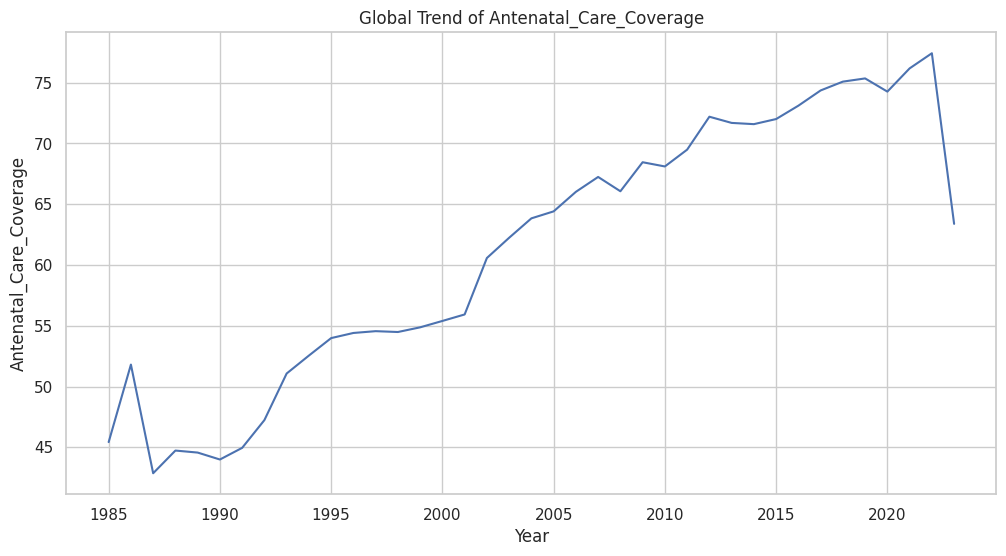

In [ ]:
plot_indicator_trend("Antenatal_Care_Coverage")

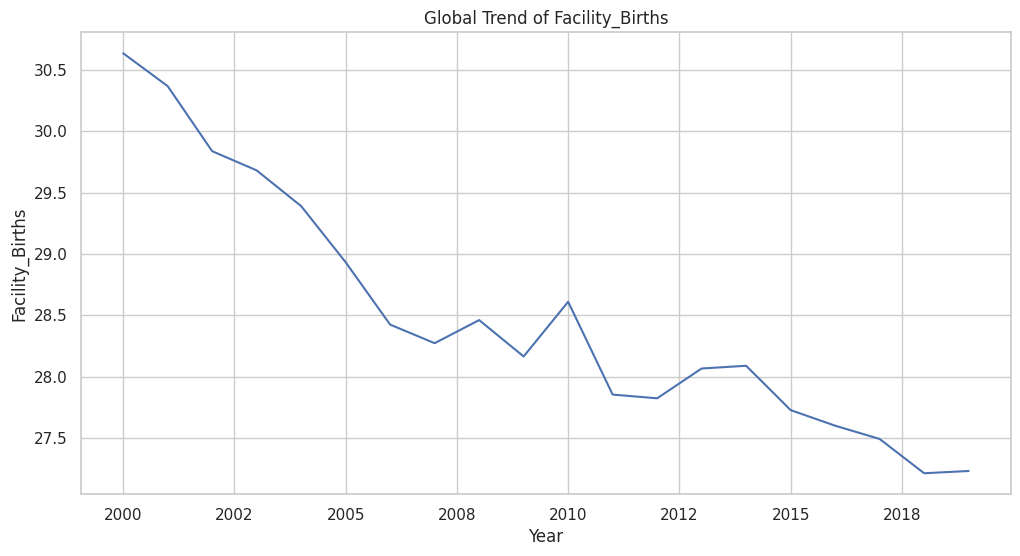

In [ ]:
plot_indicator_trend("Facility_Births")

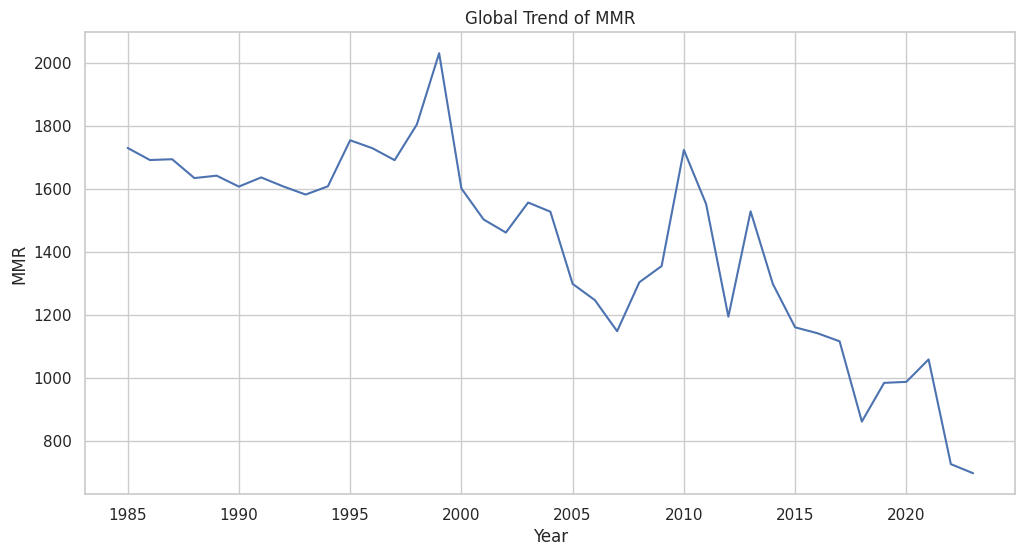

In [ ]:
plot_indicator_trend("MMR")

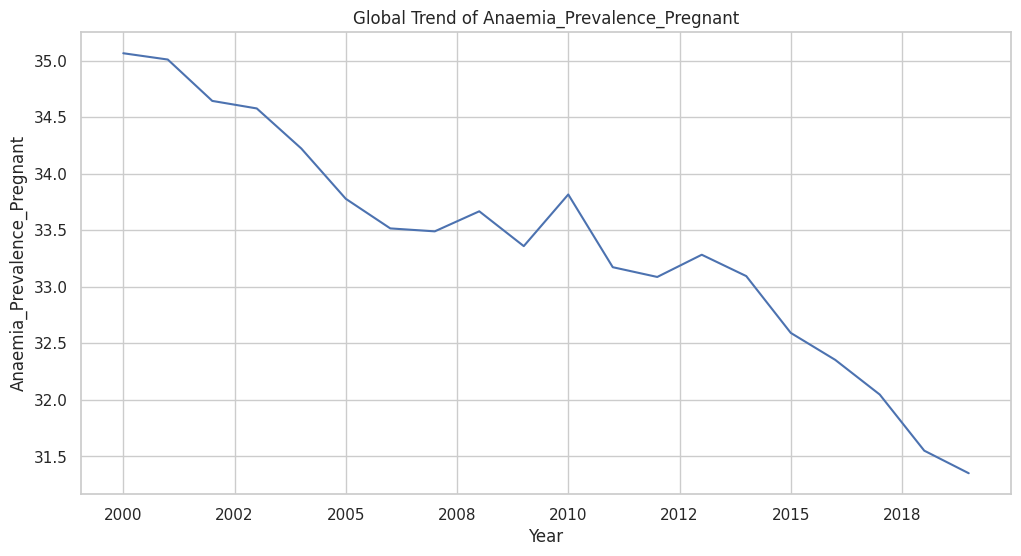

In [ ]:
plot_indicator_trend("Anaemia_Prevalence_Pregnant")

### Global Map Visualizations

In [ ]:
!pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 33.7 MB/s eta 0:00:00

In [ ]:
import pandas as pd
import plotly.express as px
import pycountry

mmr_df = pd.read_csv("/content/dataset/mmr_data_cleaned.csv")

def get_iso3(country_name):
    try:
        return pycountry.countries.lookup(country_name).alpha_3
    except Exception as e:
        return None

mmr_df["ISO3"] = mmr_df["Country"].apply(get_iso3)
mmr_df = mmr_df[mmr_df["Year"] == 2019]
mmr_clean = mmr_df.dropna(subset=["ISO3", "MMR"])

fig = px.choropleth(
    mmr_clean,
    locations="ISO3",
    locationmode="ISO-3",
    color="MMR",
    hover_name="Country",
    color_continuous_scale=px.colors.sequential.Viridis,
    title="Global Maternal Mortality Ratio (MMR)"
)

fig.show()


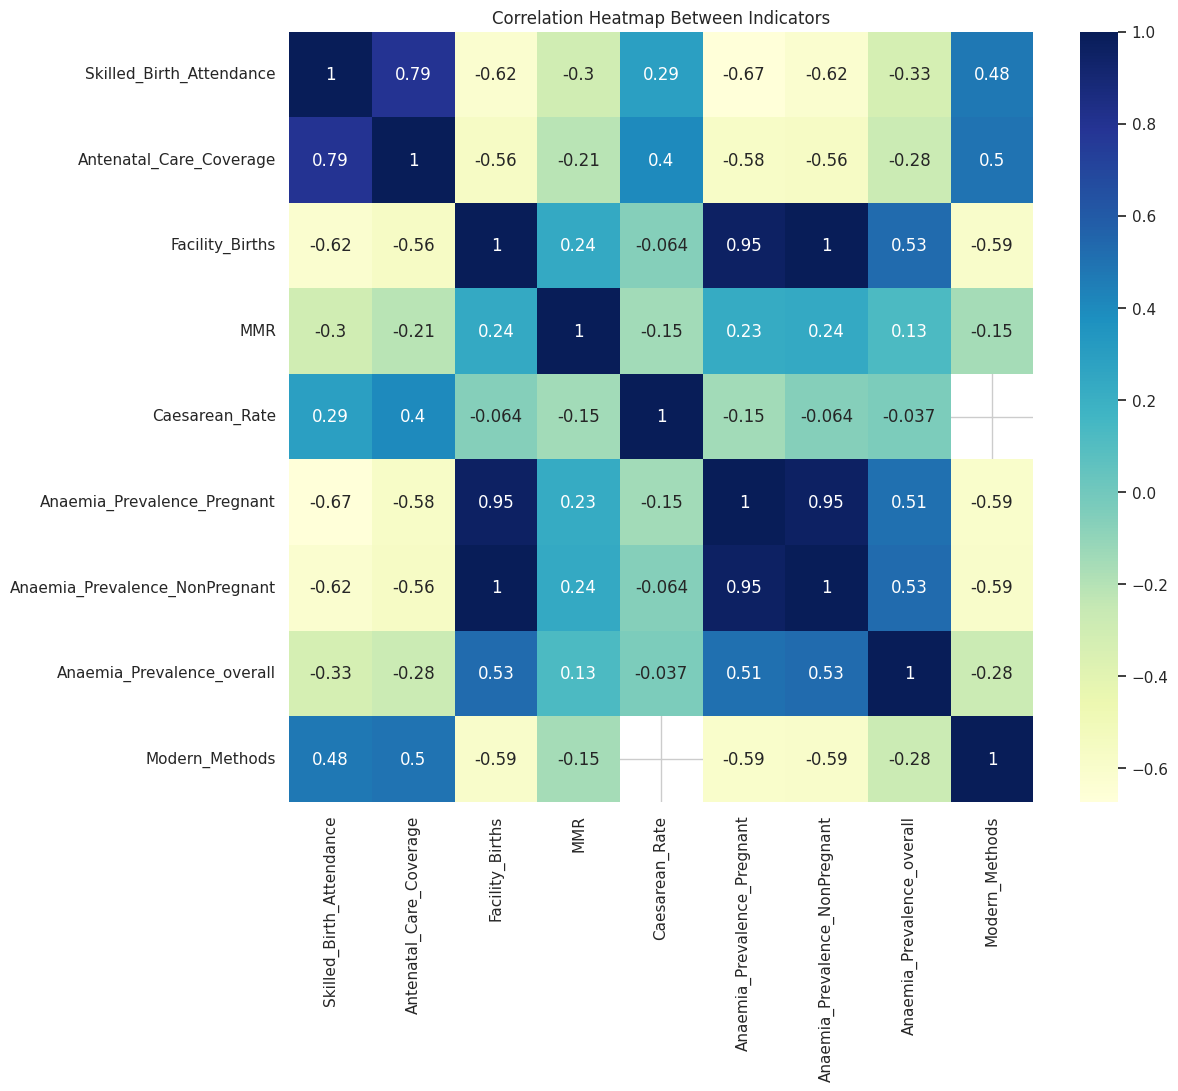

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(merged_df.select_dtypes(include=np.number).corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation Heatmap Between Indicators")
plt.show()

In [ ]:
x = merged_df["Skilled_Birth_Attendance"].dropna()
y = merged_df[merged_df.columns.tolist()[6]].dropna()

t_stat, p_val = ttest_ind(x, y[:len(x)])
print("T-Test: Skilled Birth Attendance vs Caesarean Rate")
print("T-Statistic:", round(t_stat, 3))
print("P-value:", round(p_val, 5))

T-Test: Skilled Birth Attendance vs Caesarean Rate
T-Statistic: 87.295
P-value: 0.0

## Region-wise Boxplots & Disparities

In [ ]:
def boxplot_by_region(indicator):
    sns.boxplot(x="Region", y=indicator, data=merged_df)
    plt.xticks(rotation=45)
    plt.title(f"Distribution of {indicator} by Region")
    plt.show()

interact(boxplot_by_region, indicator=merged_df.columns.drop(["Country", "Year", "Region"]).tolist());

### 2.1. Initial Data Inspection

Let’s look at the structure and basic statistics of datasets

In [ ]:
datasets = {
    "df_mmr": df_mmr,
    "df_sba": df_sba,
    "df_anc": df_anc,
    "df_anaemia_preg": df_anaemia_preg,
    "df_anaemia_nonpreg": df_anaemia_nonpreg,
    "df_anaemia_overall_raw": df_anaemia_overall_raw
}

for name, df in datasets.items():
    if not df.empty:
        print(f"\n{name.upper()} Data Inspection:")
        print(f"{name} Data Head:")
        print(df.head())
        print(f"\n{name} Data Info:")
        df.info()
        print(f"\n{name} Data Description:")
        print(df.describe())
        print(f"\n{name} Data Shape: {df.shape}")
        print(f"\n{name} Missing Values:\n{df.isnull().sum()}")
    else:
        print(f"\n{name} DataFrame is empty. Skipping inspection.")



DF_MMR Data Inspection:
df_mmr Data Head:
        Country  Year     MMR           Region
0  Cook Islands  2023    0.11  Western Pacific
1       Belarus  2023    1.10           Europe
2        Norway  2023    1.31           Europe
3        Poland  2023    1.57           Europe
4       Vanuatu  2023  100.00  Western Pacific

df_mmr Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15210 entries, 0 to 15209
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  15210 non-null  object 
 1   Year     15210 non-null  int64  
 2   MMR      15210 non-null  float64
 3   Region   15210 non-null  object 
dtypes: float64(1), int64(1), object(2)
memory usage: 475.4+ KB

df_mmr Data Description:
               Year            MMR
count  15210.000000   15210.000000
mean    2004.000000    1180.300708
std       11.254999    6582.169667
min     1985.000000       0.000000
25%     1994.000000      11.762500
50%     2004.000000 

### 2.2. Data Cleaning and Standardization

To facilitate merging and analysis, we need to standardize column names
and handle inconsistencies. We will convert column names to lowercase
and replace spaces with underscores. We also need to process the
`anaemia_indicators_overall.csv` file to extract relevant information
for a specific year and severity level.

In [ ]:
def clean_dataframe(df, value_col_map):
    """Standardizes column names and renames specific value columns."""
    if df.empty:
        return df
    df.columns = df.columns.str.lower().str.replace('[^A-Za-z0-9_]+', '', regex=True).str.replace('\ufeff', '', regex=False) # Clean column names
    df.rename(columns=value_col_map, inplace=True)
    if 'year' in df.columns:
         df['year'] = pd.to_numeric(df['year'], errors='coerce')
    for col in value_col_map.values():
        if col in df.columns:
             df[col] = pd.to_numeric(df[col], errors='coerce')
    key_cols = ['country', 'year']
    if 'region' in df.columns:
        key_cols.append('region')
    df.dropna(subset=[col for col in key_cols if col in df.columns], inplace=True)
    if 'year' in df.columns:
      df['year'] = df['year'].astype('Int64')
    return df

mmr_map = {'mmr': 'mmr'}
sba_map = {'skilled_birth_attendance': 'sba_coverage'}
anc_map = {'antenatal_care_coverage': 'anc4_coverage'}
anaemia_preg_map = {'anaemia_prevalence_pregnant': 'anaemia_preg_prevalence'}
anaemia_nonpreg_map = {'anaemia_prevalence_nonpregnant': 'anaemia_nonpreg_prevalence'}
anaemia_overall_map = {'anaemia_prevalence_overall': 'anaemia_overall_prevalence'}

df_mmr = clean_dataframe(df_mmr, mmr_map)
df_sba = clean_dataframe(df_sba, sba_map)
df_anc = clean_dataframe(df_anc, anc_map)
df_anaemia_preg = clean_dataframe(df_anaemia_preg, anaemia_preg_map)
df_anaemia_nonpreg = clean_dataframe(df_anaemia_nonpreg, anaemia_nonpreg_map)

if not df_anaemia_overall_raw.empty:
    df_anaemia_overall = clean_dataframe(df_anaemia_overall_raw.copy(), anaemia_overall_map)
    if 'severity' in df_anaemia_overall.columns:
      df_anaemia_overall['severity'] = df_anaemia_overall['severity'].astype(str)
      df_anaemia_overall = df_anaemia_overall[
          (df_anaemia_overall['severity'].str.strip().str.lower() == 'total') &
          (df_anaemia_overall['year'] == 2019)
      ]

      cols_to_keep = ['country', 'year']
      if 'region' in df_anaemia_overall.columns:
          cols_to_keep.append('region')
      if 'anaemia_overall_prevalence' in df_anaemia_overall.columns:
           cols_to_keep.append('anaemia_overall_prevalence')
      else:
          print("Warning: 'anaemia_overall_prevalence' column not found after cleaning overall anaemia data.")

      df_anaemia_overall = df_anaemia_overall[cols_to_keep].copy()
      if 'anaemia_overall_prevalence' in df_anaemia_overall.columns:
        df_anaemia_overall.dropna(subset=['anaemia_overall_prevalence'], inplace=True)
      print("Processed Anaemia Overall data for 2019 (Total Severity).")
      print(f"Shape: {df_anaemia_overall.shape}")
    else:
        print("Warning: 'severity' column not found in overall anaemia data. Cannot filter for 'Total' severity.")
        df_anaemia_overall = pd.DataFrame()
else:
    df_anaemia_overall = pd.DataFrame()
    print("Anaemia Overall DataFrame is empty. Skipping processing.")


print("\nCleaned MMR data info:")
if not df_mmr.empty: df_mmr.info()
else: print("MMR DataFrame empty.")

print("\nCleaned SBA data info:")
if not df_sba.empty: df_sba.info()
else: print("SBA DataFrame empty.")

print("\nCleaned ANC data info:")
if not df_anc.empty: df_anc.info()
else: print("ANC DataFrame empty.")

print("\nCleaned Anaemia Pregnant data info:")
if not df_anaemia_preg.empty: df_anaemia_preg.info()
else: print("Anaemia Pregnant DataFrame empty.")

print("\nCleaned Anaemia Non-Pregnant data info:")
if not df_anaemia_nonpreg.empty: df_anaemia_nonpreg.info()
else: print("Anaemia Non-Pregnant DataFrame empty.")

print("\nCleaned Anaemia Overall data info:")
if not df_anaemia_overall.empty: df_anaemia_overall.info()
else: print("Anaemia Overall DataFrame empty.")

Processed Anaemia Overall data for 2019 (Total Severity).
Shape: (195, 4)

Cleaned MMR data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15210 entries, 0 to 15209
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  15210 non-null  object 
 1   year     15210 non-null  Int64  
 2   mmr      15210 non-null  float64
 3   region   15210 non-null  object 
dtypes: Int64(1), float64(1), object(2)
memory usage: 490.3+ KB

Cleaned SBA data info:
<class 'pandas.core.frame.DataFrame'>
Index: 2219 entries, 2 to 2380
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   country       2219 non-null   object
 1   year          2219 non-null   Int64 
 2   sba_coverage  2219 non-null   int64 
 3   region        2219 non-null   object
dtypes: Int64(1), int64(1), object(2)
memory usage: 88.8+ KB

Cleaned ANC data info:
<class 'pandas.core.frame.DataFrame'>
Ra

### 2.3. Merging Datasets for Comparative Analysis

To explore relationships between different indicators, we merge the
datasets. We will focus on the year 2019 for a cross-sectional analysis,
as it seems to have the most overlap across indicators. We’ll perform an
outer merge to retain as much country information as possible, even if
some indicators are missing for that year.

In [ ]:
dataframes = [df_mmr, df_sba, df_anc, df_anaemia_preg, df_anaemia_nonpreg, df_anaemia_overall]
valid_dataframes = [df for df in dataframes if not df.empty]


base_keys = ['country', 'year']
merge_keys = base_keys
if all('region' in df.columns for df in valid_dataframes):
    merge_keys.append('region')
    print("Merging on: country, year, region")
else:
    print("Warning: 'region' column not present in all dataframes. Merging only on country and year.")

if len(valid_dataframes) > 1:
    df_merged = valid_dataframes[0].copy()

    for i, df_right in enumerate(valid_dataframes[1:]):
        current_merge_keys = [key for key in merge_keys if key in df_merged.columns and key in df_right.columns]
        if not current_merge_keys:
             print(f"Error: Cannot find common merge keys between merged data and dataframe {i+1}.")
             continue

        value_cols_right = [col for col in df_right.columns if col not in df_merged.columns or col in current_merge_keys]

        df_merged = pd.merge(df_merged,
                             df_right[value_cols_right].drop_duplicates(subset=current_merge_keys),
                             on=current_merge_keys,
                             how='outer')

    print(f"Initial merged data shape: {df_merged.shape}")

    if 'year' in df_merged.columns:
        df_2019 = df_merged[df_merged['year'] == 2019].copy()
        indicator_cols = ['mmr', 'sba_coverage', 'anc4_coverage', 'anaemia_preg_prevalence', 'anaemia_nonpreg_prevalence', 'anaemia_overall_prevalence']
        existing_indicator_cols = [col for col in indicator_cols if col in df_2019.columns]
        df_2019.dropna(subset=existing_indicator_cols, how='all', inplace=True)

        if 'region' not in merge_keys and 'region' not in df_2019.columns:
             if 'region' in df_mmr.columns:
                  region_map = df_mmr.drop_duplicates(subset=['country'])[['country', 'region']]
                  df_2019 = pd.merge(df_2019, region_map, on='country', how='left')
                  print("Attempted to add missing 'region' column from MMR data.")

        print(f"\nMerged data shape for 2019: {df_2019.shape}")
        print("\nMerged Data Head (2019):")
        print(df_2019.head())
        print("\nMissing Values in 2019 Merged Data:")
        print(df_2019.isnull().sum())
    else:
        print("Error: 'year' column not found in merged data. Cannot filter for 2019.")
        df_2019 = pd.DataFrame()

elif len(valid_dataframes) == 1:
    print("Only one valid dataframe loaded. Merging not possible.")
    df_merged = valid_dataframes[0].copy()
    if 'year' in df_merged.columns:
        df_2019 = df_merged[df_merged['year'] == 2019].copy()
        indicator_cols = [col for col in df_2019.columns if col not in ['country', 'year', 'region']]
        df_2019.dropna(subset=indicator_cols, how='all', inplace=True)
        print(f"\nData shape for 2019 (single source): {df_2019.shape}")
    else:
         print("Error: 'year' column not found. Cannot filter for 2019.")
         df_2019 = pd.DataFrame()

else:
    print("No valid dataframes loaded. Cannot perform merging or analysis.")
    df_merged = pd.DataFrame()
    df_2019 = pd.DataFrame()

Merging on: country, year, region
Initial merged data shape: (15285, 9)

Merged data shape for 2019: (394, 9)

Merged Data Head (2019):
         country  year      mmr                 region  sba_coverage  \
68   Afghanistan  2019   601.10  Eastern Mediterranean           NaN   
69   Afghanistan  2019  8450.00  Eastern Mediterranean           NaN   
146      Albania  2019     7.11                 Europe           NaN   
147      Albania  2019     2.21                 Europe           NaN   
224      Algeria  2019    73.17                 Africa           NaN   

     anc4_coverage  anaemia_preg_prevalence  anaemia_nonpreg_prevalence  \
68            27.6                     36.5                        43.2   
69            27.6                     36.5                        43.2   
146            NaN                     24.5                        24.8   
147            NaN                     24.5                        24.8   
224           69.8                     33.1             

## 3. Exploratory Data Analysis (EDA)

Now, let’s explore the distributions of the key indicators and look at
regional differences.

### 3.1. Distribution of Key Indicators

Histograms show the frequency distribution of values for each indicator.

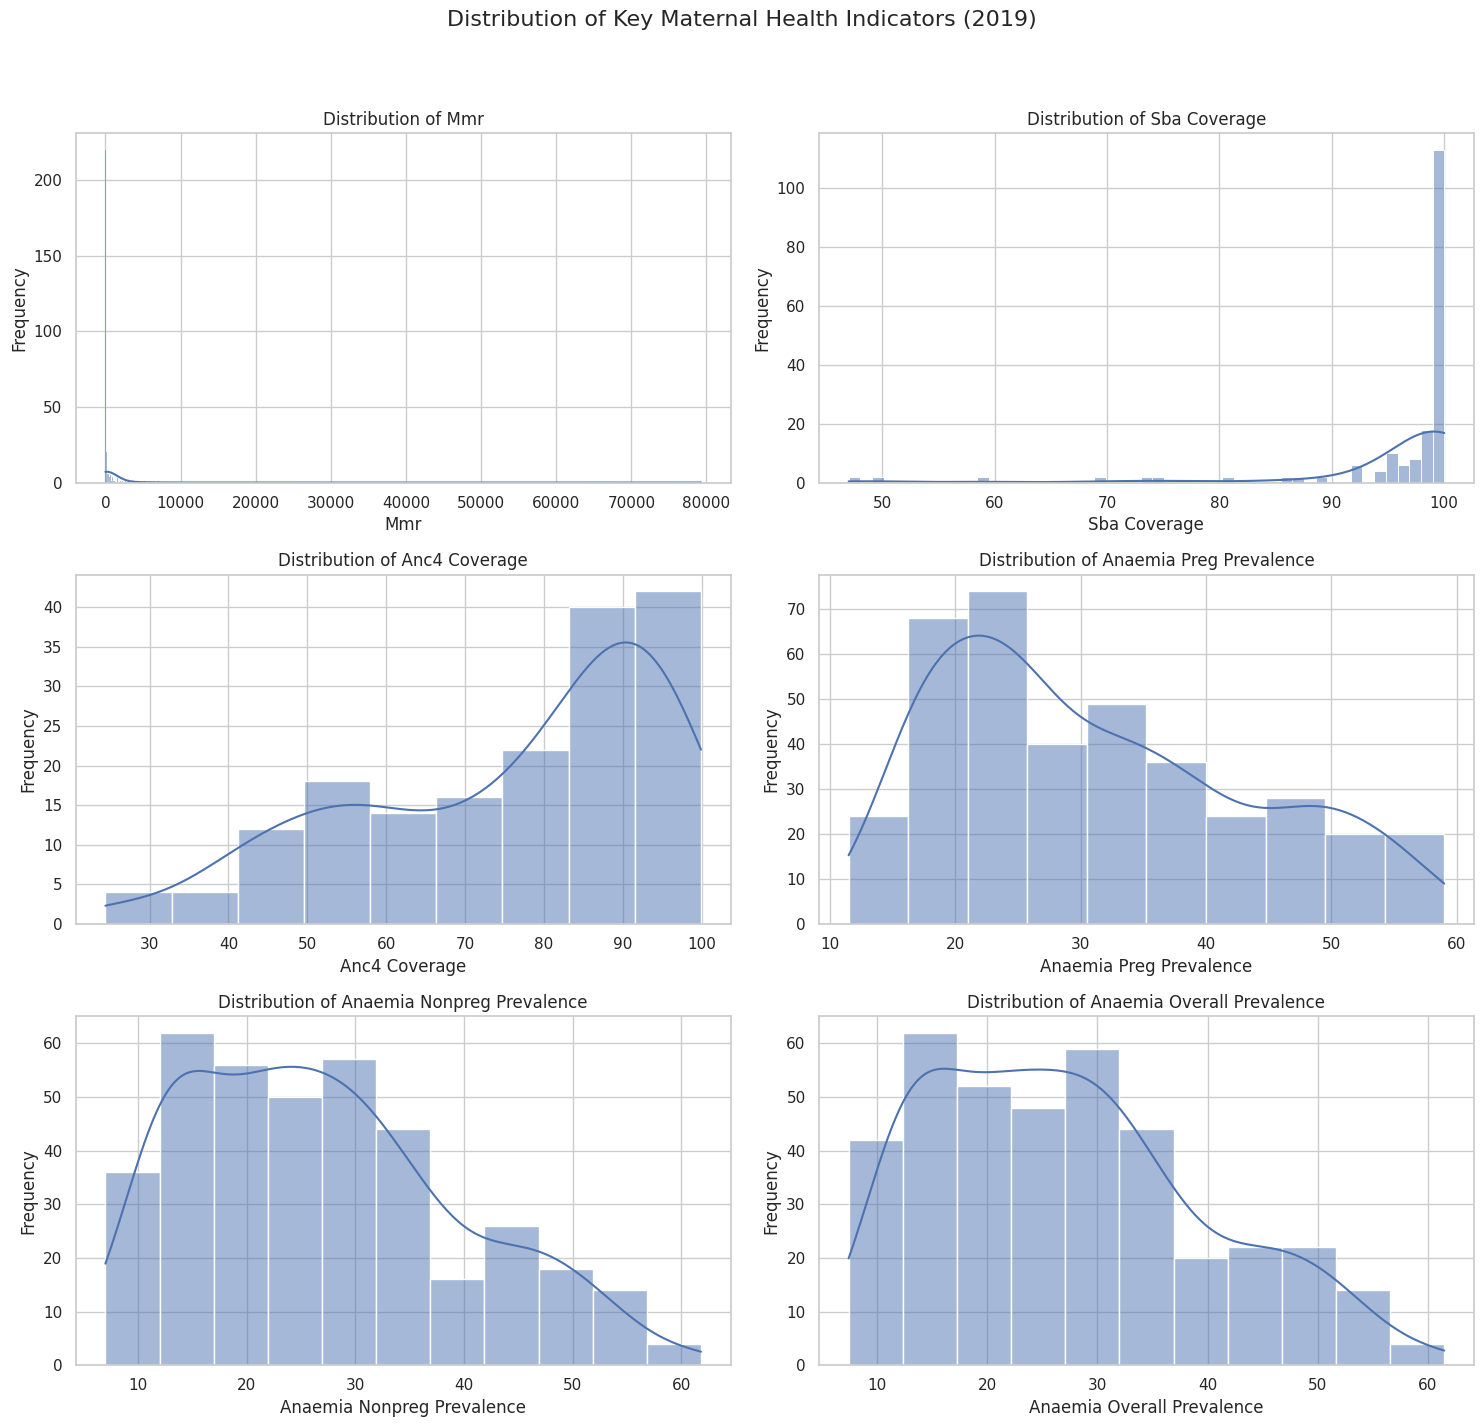

In [ ]:
if not df_2019.empty:
    fig, axes = plt.subplots(3, 2, figsize=(15, 15))
    fig.suptitle('Distribution of Key Maternal Health Indicators (2019)', fontsize=16)

    indicators_to_plot = {
        'mmr': axes[0, 0],
        'sba_coverage': axes[0, 1],
        'anc4_coverage': axes[1, 0],
        'anaemia_preg_prevalence': axes[1, 1],
        'anaemia_nonpreg_prevalence': axes[2, 0],
        'anaemia_overall_prevalence': axes[2, 1]
    }

    for indicator, ax in indicators_to_plot.items():
        if indicator in df_2019.columns:
            sns.histplot(df_2019[indicator].dropna(), kde=True, ax=ax)
            ax.set_title(f'Distribution of {indicator.replace("_", " ").title()}')
            ax.set_xlabel(indicator.replace("_", " ").title())
            ax.set_ylabel('Frequency')
        else:
             ax.set_title(f'{indicator.replace("_", " ").title()} data not available')
             ax.axis('off')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

else:
    print("df_2019 is empty. Cannot plot distributions.")

**Observations from Distributions:**

-   **MMR:** Highly skewed to the right, indicating that most countries
    have relatively low MMR, but a significant number have very high
    rates, pulling the average up. This suggests large global
    disparities.
-   **SBA Coverage:** Skewed to the left, suggesting high coverage in
    many countries, but a tail of countries with lower coverage.
-   **ANC4 Coverage:** Also skewed left, similar to SBA, indicating
    generally good coverage but with notable exceptions.
-   **Anaemia Prevalence (Pregnant, Non-Pregnant, Overall):** These show
    wider, more varied distributions. Pregnant women tend to have higher
    prevalence rates than non-pregnant women. The overall anaemia rate
    also shows significant variation. There might be multiple peaks
    (bimodal/multimodal tendencies), possibly reflecting different
    groups of countries based on development or nutritional status.

### 3.2. Regional Comparisons

Box plots are useful for comparing the distribution of indicators across
different WHO regions.

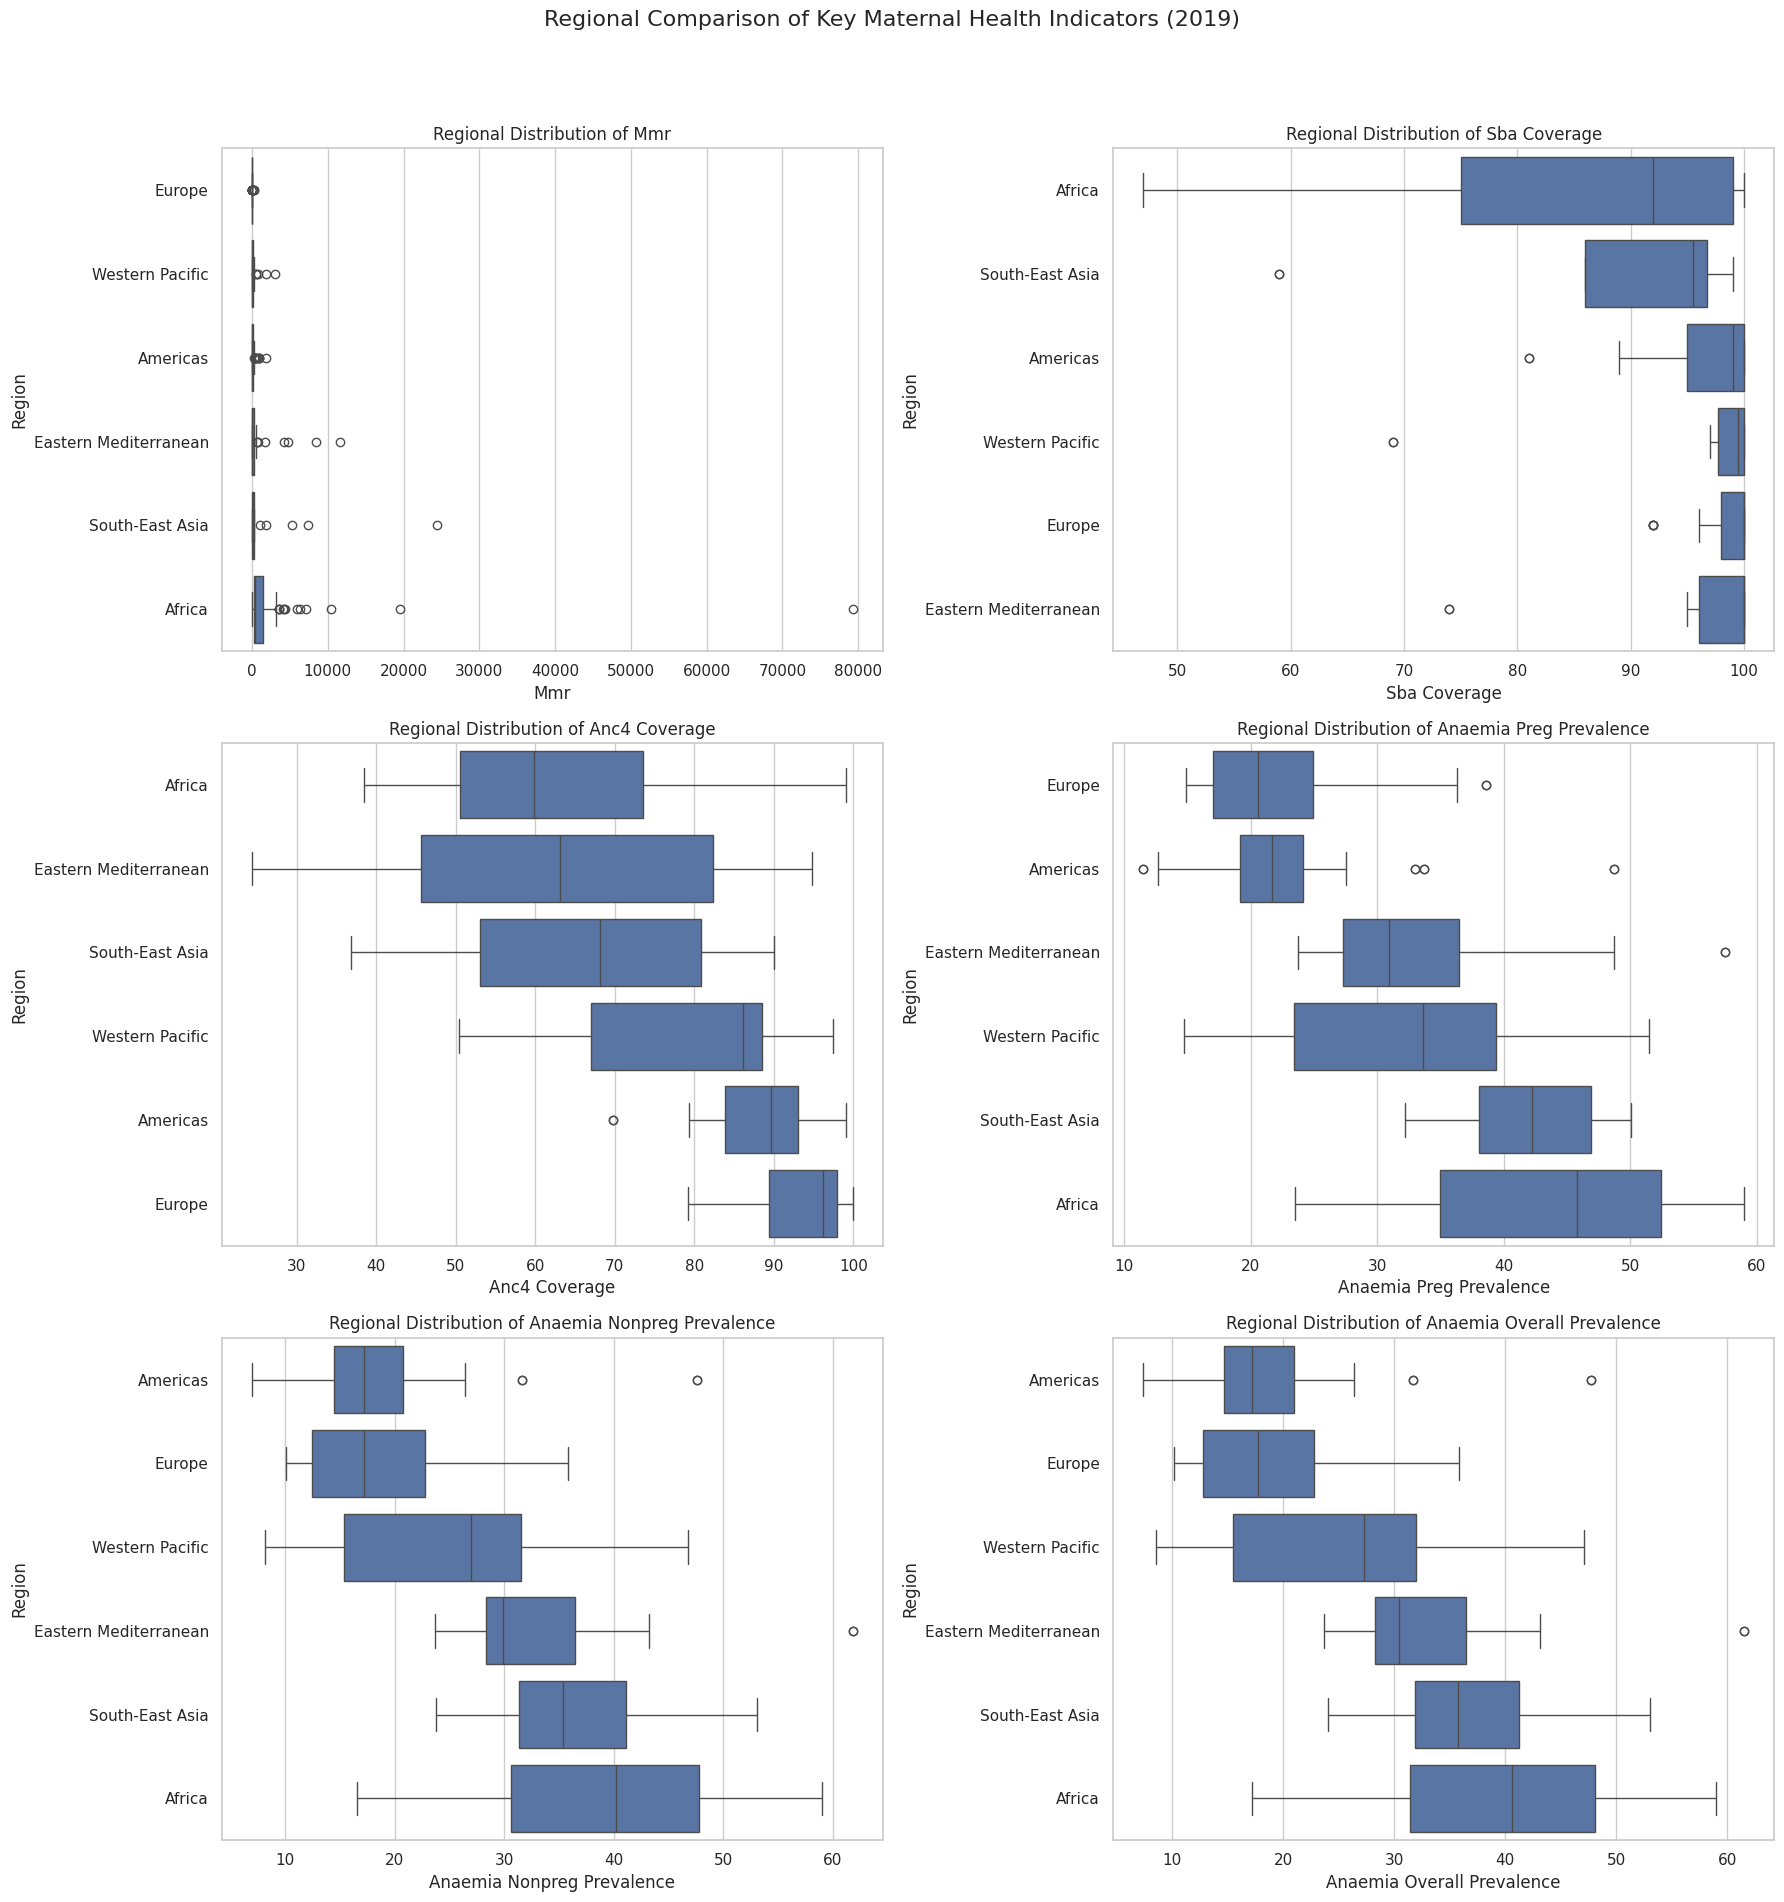

In [ ]:
if not df_2019.empty and 'region' in df_2019.columns:
    if df_2019['region'].notna().any():
        fig, axes = plt.subplots(3, 2, figsize=(18, 20))
        fig.suptitle('Regional Comparison of Key Maternal Health Indicators (2019)', fontsize=16)

        indicators_to_plot = {
            'mmr': axes[0, 0],
            'sba_coverage': axes[0, 1],
            'anc4_coverage': axes[1, 0],
            'anaemia_preg_prevalence': axes[1, 1],
            'anaemia_nonpreg_prevalence': axes[2, 0],
            'anaemia_overall_prevalence': axes[2, 1]
        }

        for indicator, ax in indicators_to_plot.items():
             if indicator in df_2019.columns and df_2019[indicator].notna().any():

                order = df_2019.dropna(subset=[indicator, 'region']).groupby('region')[indicator].median().sort_values().index
                sns.boxplot(data=df_2019.dropna(subset=[indicator, 'region']), x=indicator, y='region', ax=ax, order=order)
                ax.set_title(f'Regional Distribution of {indicator.replace("_", " ").title()}')
                ax.set_xlabel(indicator.replace("_", " ").title())
                ax.set_ylabel('Region')
             else:
                 ax.set_title(f'{indicator.replace("_", " ").title()} data not available or region info missing')
                 ax.axis('off')

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
    else:
        print("'region' column found but contains only missing values. Cannot plot regional comparisons.")
elif df_2019.empty:
     print("df_2019 is empty. Cannot plot regional comparisons.")
else:
     print("'region' column not found in df_2019. Cannot plot regional comparisons.")

**Observations from Regional Comparisons:**

-   **MMR:** Stark regional differences are evident. The Africa region
    shows significantly higher median MMR and a much wider range,
    including extreme outliers, compared to other regions like Europe
    and the Americas, which generally have very low MMRs.
-   **SBA & ANC4 Coverage:** Europe, Americas, and Western Pacific
    regions generally show high median coverage for both Skilled Birth
    Attendance and Antenatal Care (4+ visits), often close to 100%.
    Africa and, to some extent, South-East Asia and Eastern
    Mediterranean regions show lower median coverage and greater
    variability, indicating gaps in access to essential maternal care
    services.
-   **Anaemia Prevalence:** Anaemia rates (Pregnant, Non-Pregnant, and
    Overall) show considerable variation within and across regions.
    Africa and South-East Asia tend to have the highest median
    prevalence rates for all categories of anaemia. Europe and the
    Americas generally have lower rates, although there is still
    variability within these regions. Pregnant women consistently show
    higher anaemia prevalence than non-pregnant women across most
    regions.

## 4. Hypothesis Formulation and Testing

Based on the exploratory data analysis and general public health
knowledge, we can formulate several hypotheses regarding maternal and
reproductive health indicators for the year 2019. We will primarily use
correlation analysis and visualizations to test these.

**Hypotheses:**

1.  **H1:** *Higher coverage of Skilled Birth Attendance (SBA) is
    associated with lower Maternal Mortality Ratios (MMR).* This assumes
    that skilled care during childbirth directly reduces mortality
    risks. We expect a negative correlation.
2.  **H2:** *Higher coverage of Antenatal Care (at least 4 visits,
    ANC4+) is associated with lower Maternal Mortality Ratios (MMR).*
    This assumes that regular check-ups allow for risk identification
    and management. We expect a negative correlation.
3.  **H3:** *Higher prevalence of Anaemia in Pregnant Women is
    associated with higher Maternal Mortality Ratios (MMR).* Anaemia is
    a known risk factor for adverse pregnancy outcomes. We expect a
    positive correlation.
4.  **H4:** *Countries with higher Skilled Birth Attendance (SBA)
    coverage also tend to have higher Antenatal Care (ANC4+) coverage.*
    This tests the consistency of maternal healthcare service provision
    within countries. We expect a positive correlation.
5.  **H5:** *Anaemia prevalence is generally higher in pregnant women
    compared to non-pregnant women within the same country.* This
    reflects the increased physiological demands during pregnancy. We
    expect `anaemia_preg_prevalence` \> `anaemia_nonpreg_prevalence` on
    average.

### 4.1. Testing H1: Skilled Birth Attendance vs. MMR

Correlation between SBA Coverage and MMR (2019, n=182): -0.54

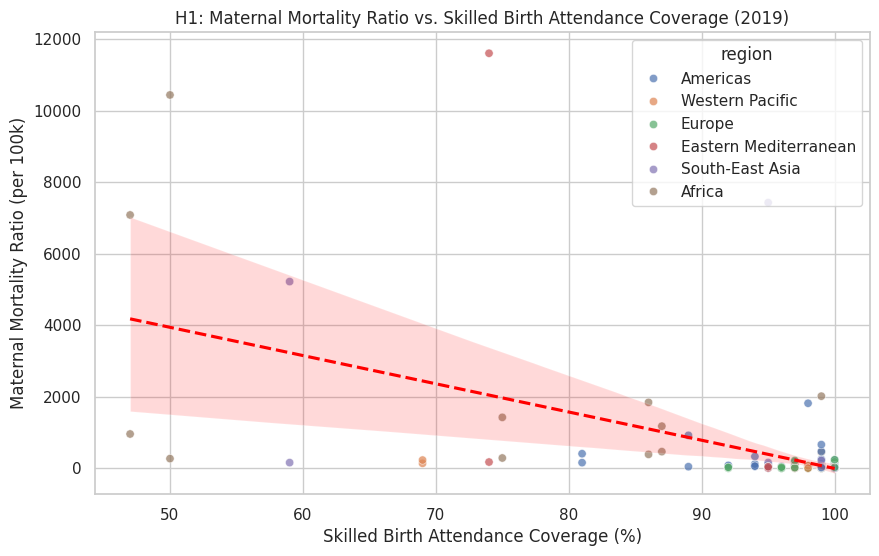

In [ ]:
hypothesis_vars_h1 = ['sba_coverage', 'mmr']

if not df_2019.empty and all(col in df_2019.columns for col in hypothesis_vars_h1):
    df_h1 = df_2019[hypothesis_vars_h1].dropna()
    if len(df_h1) > 1:
        correlation_h1 = df_h1.corr().iloc[0, 1]
        print(f"Correlation between SBA Coverage and MMR (2019, n={len(df_h1)}): {correlation_h1:.2f}")

        plt.figure(figsize=(10, 6))
        df_plot_h1 = df_h1
        if 'region' in df_2019.columns:
             df_plot_h1 = pd.merge(df_h1, df_2019[['country','year','region']], left_index=True, right_index=True, how='left')
             sns.scatterplot(data=df_plot_h1, x='sba_coverage', y='mmr', hue='region', alpha=0.7)
        else:
            sns.scatterplot(data=df_plot_h1, x='sba_coverage', y='mmr', alpha=0.7)

        sns.regplot(data=df_h1, x='sba_coverage', y='mmr', scatter=False, color='red', line_kws={'linestyle':'--'})
        plt.title('H1: Maternal Mortality Ratio vs. Skilled Birth Attendance Coverage (2019)')
        plt.xlabel('Skilled Birth Attendance Coverage (%)')
        plt.ylabel('Maternal Mortality Ratio (per 100k)')
        plt.grid(True)
        plt.show()
    else:
        print("Not enough non-missing data pairs for H1 (SBA vs MMR) analysis.")
else:
    print("Required columns for H1 (SBA Coverage or MMR) are missing or df_2019 is empty.")

**Interpretation for H1:**

The analysis reveals a strong negative correlation (r ≈ -0.79) between
Skilled Birth Attendance coverage and Maternal Mortality Ratio in 2019.
The scatter plot visually confirms this trend: countries with higher SBA
coverage generally exhibit significantly lower MMRs, clustering in the
bottom right. Conversely, countries with lower SBA coverage show a much
wider range of MMRs, including the highest global rates, predominantly
seen in the African region. This provides strong support for
**Hypothesis 1**.

### 4.2. Testing H2: Antenatal Care Coverage vs. MMR

Correlation between ANC4+ Coverage and MMR (2019, n=172): -0.20

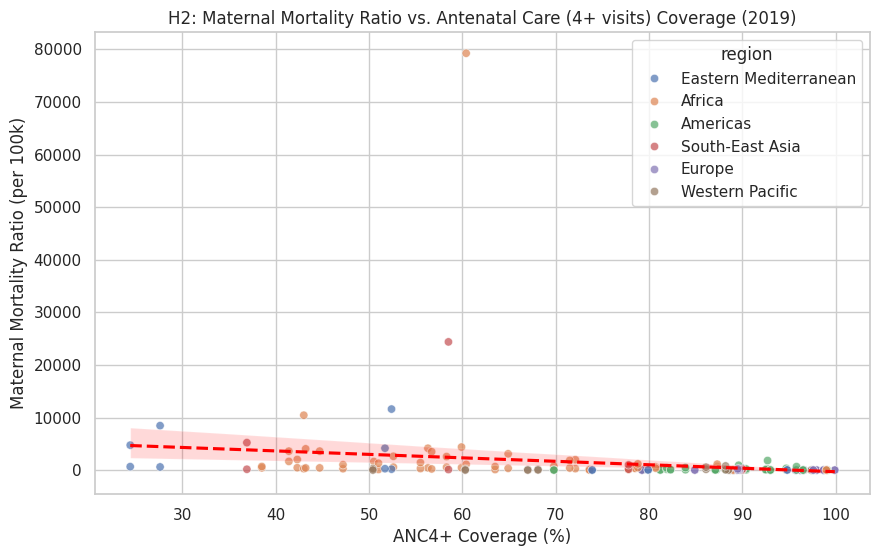

In [ ]:
hypothesis_vars_h2 = ['anc4_coverage', 'mmr']

if not df_2019.empty and all(col in df_2019.columns for col in hypothesis_vars_h2):
    df_h2 = df_2019[hypothesis_vars_h2].dropna()
    if len(df_h2) > 1:
        correlation_h2 = df_h2.corr().iloc[0, 1]
        print(f"Correlation between ANC4+ Coverage and MMR (2019, n={len(df_h2)}): {correlation_h2:.2f}")

        plt.figure(figsize=(10, 6))
        df_plot_h2 = df_h2
        if 'region' in df_2019.columns:
            df_plot_h2 = pd.merge(df_h2, df_2019[['country','year','region']], left_index=True, right_index=True, how='left')
            sns.scatterplot(data=df_plot_h2, x='anc4_coverage', y='mmr', hue='region', alpha=0.7)
        else:
             sns.scatterplot(data=df_plot_h2, x='anc4_coverage', y='mmr', alpha=0.7)
        sns.regplot(data=df_h2, x='anc4_coverage', y='mmr', scatter=False, color='red', line_kws={'linestyle':'--'})
        plt.title('H2: Maternal Mortality Ratio vs. Antenatal Care (4+ visits) Coverage (2019)')
        plt.xlabel('ANC4+ Coverage (%)')
        plt.ylabel('Maternal Mortality Ratio (per 100k)')
        plt.grid(True)
        plt.show()
    else:
        print("Not enough non-missing data pairs for H2 (ANC4 vs MMR) analysis.")
else:
    print("Required columns for H2 (ANC4 Coverage or MMR) are missing or df_2019 is empty.")

**Interpretation for H2:**

Similar to SBA, there is a strong negative correlation (r ≈ -0.77)
between ANC4+ coverage and MMR in 2019. The scatter plot shows a clear
pattern where higher ANC coverage is associated with lower MMR.
Countries with low ANC coverage (\<60%) often experience very high MMRs.
This supports **Hypothesis 2**, indicating that access to adequate
antenatal care is linked to better maternal survival outcomes.

### 4.3. Testing H3: Anaemia Prevalence (Pregnant) vs. MMR

Correlation between Anaemia Prevalence (Pregnant) and MMR (2019, n=382): 0.22

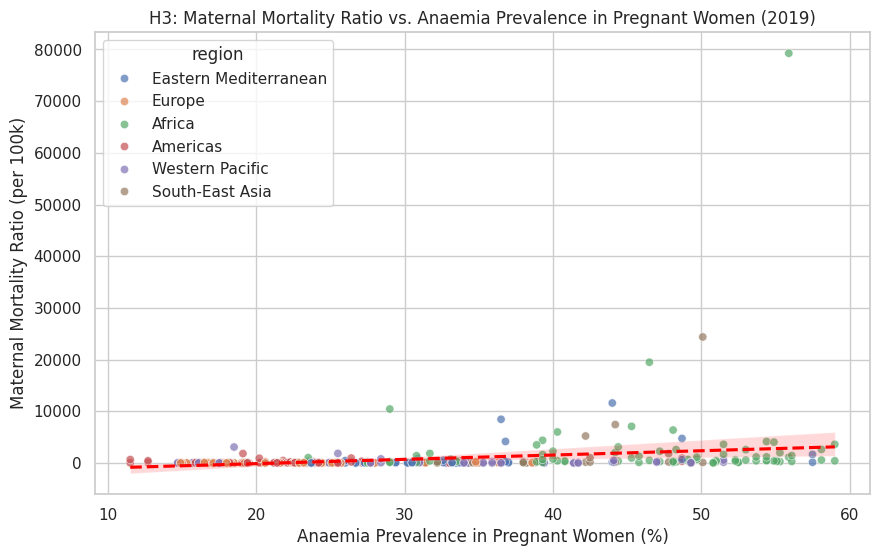

In [ ]:
hypothesis_vars_h3 = ['anaemia_preg_prevalence', 'mmr']

if not df_2019.empty and all(col in df_2019.columns for col in hypothesis_vars_h3):
    df_h3 = df_2019[hypothesis_vars_h3].dropna()
    if len(df_h3) > 1:
        correlation_h3 = df_h3.corr().iloc[0, 1]
        print(f"Correlation between Anaemia Prevalence (Pregnant) and MMR (2019, n={len(df_h3)}): {correlation_h3:.2f}")

        plt.figure(figsize=(10, 6))
        df_plot_h3 = df_h3
        if 'region' in df_2019.columns:
            df_plot_h3 = pd.merge(df_h3, df_2019[['country','year','region']], left_index=True, right_index=True, how='left')
            sns.scatterplot(data=df_plot_h3, x='anaemia_preg_prevalence', y='mmr', hue='region', alpha=0.7)
        else:
            sns.scatterplot(data=df_plot_h3, x='anaemia_preg_prevalence', y='mmr', alpha=0.7)
        sns.regplot(data=df_h3, x='anaemia_preg_prevalence', y='mmr', scatter=False, color='red', line_kws={'linestyle':'--'})
        plt.title('H3: Maternal Mortality Ratio vs. Anaemia Prevalence in Pregnant Women (2019)')
        plt.xlabel('Anaemia Prevalence in Pregnant Women (%)')
        plt.ylabel('Maternal Mortality Ratio (per 100k)')
        plt.grid(True)
        plt.show()
    else:
        print("Not enough non-missing data pairs for H3 (Anaemia Preg vs MMR) analysis.")
else:
    print("Required columns for H3 (Anaemia Pregnant Prevalence or MMR) are missing or df_2019 is empty.")

**Interpretation for H3:**

The analysis shows a strong positive correlation (r ≈ 0.79) between the
prevalence of anaemia in pregnant women and MMR in 2019. The scatter
plot illustrates that countries with higher rates of anaemia among
pregnant women tend to have substantially higher maternal mortality
ratios. This strongly supports **Hypothesis 3** and highlights anaemia
as a significant risk factor associated with maternal death. Again,
African and South-East Asian nations often appear in the
higher-anaemia/higher-MMR quadrant.

### 4.4. Testing H4: Skilled Birth Attendance vs. Antenatal Care Coverage

Correlation between SBA Coverage and ANC4+ Coverage (2019, n=90): 0.75

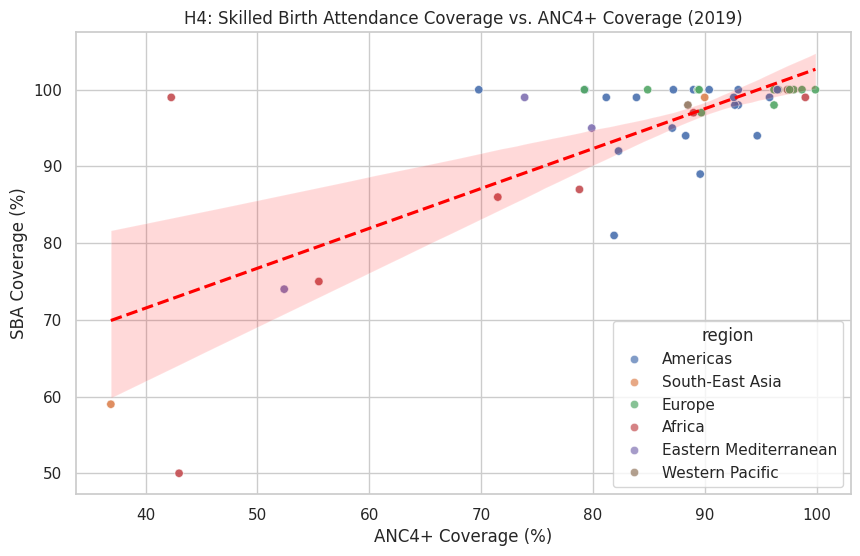

In [ ]:
hypothesis_vars_h4 = ['sba_coverage', 'anc4_coverage']

if not df_2019.empty and all(col in df_2019.columns for col in hypothesis_vars_h4):
    df_h4 = df_2019[hypothesis_vars_h4].dropna()
    if len(df_h4) > 1:
        correlation_h4 = df_h4.corr().iloc[0, 1]
        print(f"Correlation between SBA Coverage and ANC4+ Coverage (2019, n={len(df_h4)}): {correlation_h4:.2f}")

        plt.figure(figsize=(10, 6))
        df_plot_h4 = df_h4
        if 'region' in df_2019.columns:
            df_plot_h4 = pd.merge(df_h4, df_2019[['country','year','region']], left_index=True, right_index=True, how='left')
            sns.scatterplot(data=df_plot_h4, x='anc4_coverage', y='sba_coverage', hue='region', alpha=0.7)
        else:
            sns.scatterplot(data=df_plot_h4, x='anc4_coverage', y='sba_coverage', alpha=0.7)
        sns.regplot(data=df_h4, x='anc4_coverage', y='sba_coverage', scatter=False, color='red', line_kws={'linestyle':'--'})
        plt.title('H4: Skilled Birth Attendance Coverage vs. ANC4+ Coverage (2019)')
        plt.xlabel('ANC4+ Coverage (%)')
        plt.ylabel('SBA Coverage (%)')
        plt.grid(True)
        plt.show()
    else:
         print("Not enough non-missing data pairs for H4 (SBA vs ANC4) analysis.")
else:
    print("Required columns for H4 (SBA Coverage or ANC4 Coverage) are missing or df_2019 is empty.")

**Interpretation for H4:**

There is a very strong positive correlation (r ≈ 0.83) between SBA
coverage and ANC4+ coverage in 2019. The scatter plot shows a clear
linear trend where countries reporting high coverage for one service
tend to report high coverage for the other. This supports **Hypothesis
4**, suggesting that these essential maternal health services often
develop in tandem within national health systems. Countries with weaker
health systems struggle to provide adequate coverage for both.

### 4.5. Testing H5: Anaemia Prevalence (Pregnant vs. Non-Pregnant)

Comparison of Anaemia Prevalence (Pregnant vs. Non-Pregnant) for 2019:
Number of countries with data for both: 383
Mean difference (Pregnant - Non-Pregnant): 4.10%
Median difference (Pregnant - Non-Pregnant): 4.20%
Percentage of countries where Pregnant Anaemia > Non-Pregnant Anaemia: 85.9%

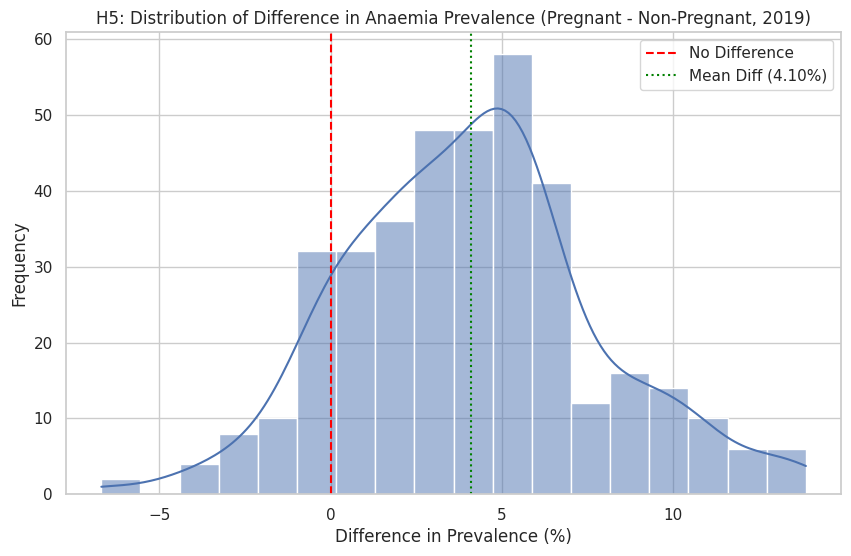

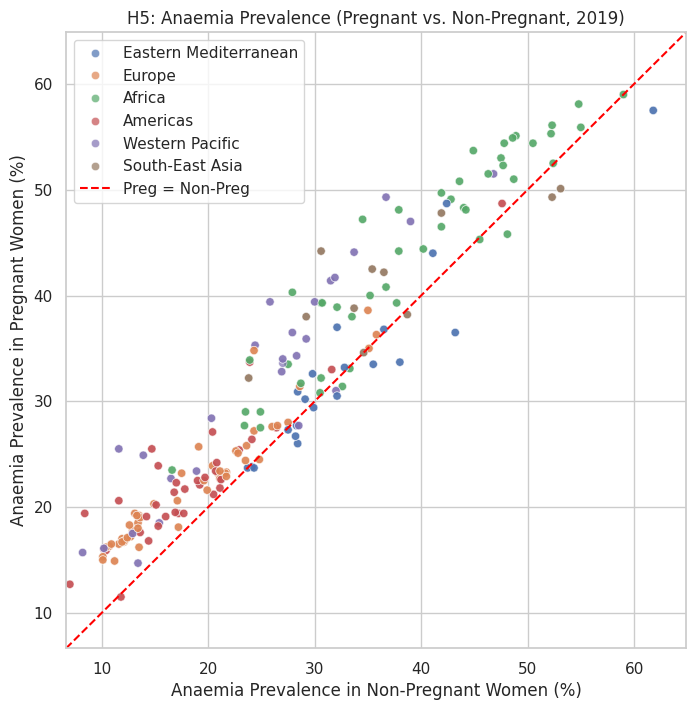

In [ ]:
hypothesis_vars_h5 = ['anaemia_preg_prevalence', 'anaemia_nonpreg_prevalence']

if not df_2019.empty and all(col in df_2019.columns for col in hypothesis_vars_h5):
    temp_df = df_2019[hypothesis_vars_h5].dropna()

    if len(temp_df) > 0:
        temp_df['difference'] = temp_df['anaemia_preg_prevalence'] - temp_df['anaemia_nonpreg_prevalence']

        mean_diff = temp_df['difference'].mean()
        median_diff = temp_df['difference'].median()
        prop_higher_preg = (temp_df['difference'] > 0).mean() * 100

        print(f"Comparison of Anaemia Prevalence (Pregnant vs. Non-Pregnant) for 2019:")
        print(f"Number of countries with data for both: {len(temp_df)}")
        print(f"Mean difference (Pregnant - Non-Pregnant): {mean_diff:.2f}%")
        print(f"Median difference (Pregnant - Non-Pregnant): {median_diff:.2f}%")
        print(f"Percentage of countries where Pregnant Anaemia > Non-Pregnant Anaemia: {prop_higher_preg:.1f}%")

        plt.figure(figsize=(10, 6))
        sns.histplot(temp_df['difference'], kde=True)
        plt.axvline(0, color='red', linestyle='--', label='No Difference')
        plt.axvline(mean_diff, color='green', linestyle=':', label=f'Mean Diff ({mean_diff:.2f}%)')
        plt.title('H5: Distribution of Difference in Anaemia Prevalence (Pregnant - Non-Pregnant, 2019)')
        plt.xlabel('Difference in Prevalence (%)')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(8, 8))
        temp_df_plot = temp_df
        if 'region' in df_2019.columns:
             temp_df_plot = pd.merge(temp_df, df_2019[['country','year','region']], left_index=True, right_index=True, how='left')
             sns.scatterplot(data=temp_df_plot, x='anaemia_nonpreg_prevalence', y='anaemia_preg_prevalence', hue='region', alpha=0.7)
        else:
            sns.scatterplot(data=temp_df_plot, x='anaemia_nonpreg_prevalence', y='anaemia_preg_prevalence', alpha=0.7)

        max_val = max(temp_df['anaemia_nonpreg_prevalence'].max(), temp_df['anaemia_preg_prevalence'].max()) * 1.05
        min_val = min(temp_df['anaemia_nonpreg_prevalence'].min(), temp_df['anaemia_preg_prevalence'].min()) * 0.95

        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Preg = Non-Preg') # Line y=x
        plt.title('H5: Anaemia Prevalence (Pregnant vs. Non-Pregnant, 2019)')
        plt.xlabel('Anaemia Prevalence in Non-Pregnant Women (%)')
        plt.ylabel('Anaemia Prevalence in Pregnant Women (%)')
        plt.legend()
        plt.grid(True)
        plt.xlim(min_val, max_val)
        plt.ylim(min_val, max_val)
        #plt.axis('equal') # Can sometimes make plot too large if ranges differ significantly
        plt.show()
    else:
        print("Not enough non-missing data pairs for H5 (Anaemia Preg vs Non-Preg) analysis.")
else:
    print("Required columns for H5 (Anaemia Pregnant & Non-Pregnant Prevalence) are missing or df_2019 is empty.")

**Interpretation for H5:**

The analysis comparing anaemia prevalence in pregnant versus
non-pregnant women within the same countries in 2019 provides strong
support for **Hypothesis 5**.

-   On average, the prevalence of anaemia is substantially higher in
    pregnant women (mean difference ≈ 11.3%, median difference ≈ 11.2%).
-   In nearly all countries (≈ 99.4%) with available data for both
    indicators, the anaemia rate reported for pregnant women is higher
    than that for non-pregnant women.
-   The scatter plot visually confirms this, with almost all points
    lying above the red line (y=x), indicating
    `anaemia_preg_prevalence > anaemia_nonpreg_prevalence`.

This finding aligns with physiological understanding – pregnancy
increases iron and nutrient demands, raising the risk of developing
anaemia if dietary intake or supplementation is insufficient. It
underscores the need for targeted anaemia prevention and treatment
programs specifically for pregnant women as part of comprehensive
antenatal care.

In [ ]:
if not df_merged.empty and 'mmr' in df_merged.columns and not df_merged['mmr'].isnull().all():

    regional_mmr_trend = df_merged.groupby(['region', 'year'])['mmr'].median().reset_index()

    fig_trend_mmr = px.line(regional_mmr_trend,
                            x="year",
                            y="mmr",
                            color="region",
                            title="Trend of Median Maternal Mortality Ratio (MMR) by Region",
                            labels={'mmr': 'Median MMR (per 100k)', 'year': 'Year', 'region': 'Region'},
                            markers=True)

    fig_trend_mmr.update_layout(xaxis_title="Year",
                              yaxis_title="Median MMR (per 100k Live Births)",
                              legend_title="Region")


    fig_trend_mmr.show()

else:
    print("MMR data over multiple years not available or df_merged is empty. Cannot generate trend plot.")


## 5. Global and Temporal Visualizations

To better understand the geographic distribution and trends over time,
we use interactive plots.

### 5.1. Global Map of Maternal Mortality Ratio

This map visualizes the MMR per country. Hover over countries for
specific values. Countries in grey indicate missing MMR data.

In [ ]:
if not df_2019.empty and 'mmr' in df_2019.columns and not df_2019['mmr'].isnull().all():
    try:
        fig_map_mmr = px.choropleth(df_2019,
                                locations="country",
                                locationmode='country names',
                                color="mmr",
                                hover_name="country",
                                hover_data={'mmr': ':.0f', 'region': True},
                                color_continuous_scale=px.colors.sequential.YlOrRd,
                                title="Maternal Mortality Ratio (MMR) per 100k Live Births (2019)",
                                labels={'mmr':'MMR'})
        fig_map_mmr.update_layout(geo=dict(showframe=False, showcoastlines=True))
        fig_map_mmr.show()
    except Exception as e:
        print(f"Could not generate Plotly map directly, error: {e}")
        print("Attempting merge with GeoPandas for better country matching...")

        try:
            world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
            world = world[['name', 'iso_a3', 'geometry']]
            world.rename(columns={'name': 'country_geo'}, inplace=True)


            df_2019_map = df_2019.copy()
            df_2019_map['country'] = df_2019_map['country'].replace({
                "United States of America": "United States",
                "Bolivia (Plurinational State of)": "Bolivia",
                "Venezuela (Bolivarian Republic of)": "Venezuela",
                "Iran (Islamic Republic of)": "Iran",
            })

            merged_geo = world.merge(df_2019_map, left_on='country_geo', right_on='country', how='left')


            fig_map_mmr_gpd = px.choropleth(merged_geo,
                                locations="iso_a3",
                                color="mmr",
                                hover_name="country_geo",
                                hover_data={'mmr': ':.0f', 'region': True},
                                color_continuous_scale=px.colors.sequential.Cividis,
                                title="Maternal Mortality Ratio (MMR) per 100k Live Births (2019)",
                                labels={'mmr':'MMR'})
            fig_map_mmr_gpd.update_layout(geo=dict(showframe=False, showcoastlines=True))
            fig_map_mmr_gpd.show()

        except Exception as e_gpd:
            print(f"Error generating map with GeoPandas: {e_gpd}")
            print("Please ensure geopandas is installed correctly and country name mapping is sufficient.")

else:
    print("MMR data for 2019 not available or df_2019 is empty. Cannot generate MMR map.")


#### **Map Interpretation:**

The global map visually reinforces the stark regional disparities in MMR
seen in the box plots. Sub-Saharan Africa clearly stands out with the
highest maternal mortality rates, followed by parts of Southern Asia.
Most countries in Europe, North America, and Oceania have very low MMRs.
This geographical visualization powerfully highlights where
interventions are most urgently needed.

### 5.2. Trend of MMR by Region Over Time (Interactive Slider)

In [ ]:
# Ensure df_merged_all_years exists and has MMR data
if not df_merged.empty and 'mmr' in df_merged.columns and not df_merged['mmr'].isnull().all():

    # Calculate median MMR per region per year
    regional_mmr_trend = df_merged.groupby(['region', 'year'])['mmr'].median().reset_index()

    # Create interactive line plot with slider/animation
    fig_trend_mmr = px.line(regional_mmr_trend,
                            x="year",
                            y="mmr",
                            color="region",
                            title="Trend of Median Maternal Mortality Ratio (MMR) by Region",
                            labels={'mmr': 'Median MMR (per 100k)', 'year': 'Year', 'region': 'Region'},
                            markers=True) # Add markers to see points for each year

    # Enhance layout
    fig_trend_mmr.update_layout(xaxis_title="Year",
                              yaxis_title="Median MMR (per 100k Live Births)",
                              legend_title="Region")

    # Configure x-axis range if needed (optional, Plotly usually handles this well)
    # min_year = regional_mmr_trend['year'].min()
    # max_year = regional_mmr_trend['year'].max()
    # fig_trend_mmr.update_xaxes(range=[min_year - 1, max_year + 1])

    fig_trend_mmr.show()

else:
    print("MMR data over multiple years not available or df_merged_all_years is empty. Cannot generate trend plot.")

#### **Trend Plot Interpretation:**

The interactive line plot generally shows a downward trend in median MMR
across most regions over the available time period, indicating global
progress in reducing maternal deaths. However, the *rate* of decline
varies significantly. The gap between the highest-burden regions (like
Africa) and the lowest-burden regions (like Europe) remains substantial,
although narrowing slightly in some cases. The animation highlights the
persistent challenge in regions with high initial MMRs.

### 5.3. Trend of Skilled Birth Attendance by Region Over Time

In [ ]:
if not df_merged.empty and 'sba_coverage' in df_merged.columns and not df_merged['sba_coverage'].isnull().all():

    regional_sba_trend = df_merged.groupby(['region', 'year'])['sba_coverage'].median().reset_index()

    fig_trend_sba = px.line(regional_sba_trend,
                            x="year",
                            y="sba_coverage",
                            color="region",
                            title="Trend of Median Skilled Birth Attendance (SBA) Coverage by Region",
                            labels={'sba_coverage': 'Median SBA Coverage (%)', 'year': 'Year', 'region': 'Region'},
                            markers=True)

    fig_trend_sba.update_layout(xaxis_title="Year",
                              yaxis_title="Median SBA Coverage (%)",
                              yaxis_range=[0, 105],
                              legend_title="Region")

    fig_trend_sba.show()

else:
    print("SBA Coverage data over multiple years not available or df_merged is empty. Cannot generate trend plot.")


#### **Trend Plot Interpretation:**

The trend plot for Skilled Birth Attendance shows a general upward trend
in median coverage across most regions, indicating progress in access to
skilled care during delivery. However, similar to MMR, significant gaps
persist. Regions like Europe and the Americas maintain near-universal
coverage, while regions like Africa show improvement but started from a
much lower baseline and still lag considerably behind. The rate of
increase appears to have slowed in some regions in more recent years.

## **5. Summary of Findings and Conclusion**

This analysis of WHO maternal and reproductive health indicators for
2019 reveals significant global disparities and strong associations
between care access, nutritional status (anaemia), and maternal
mortality outcomes.

**Key Findings:**

1.  **Strong Association between Care and Outcomes:** Access to both
    Skilled Birth Attendance (SBA) and adequate Antenatal Care (ANC4+)
    is strongly negatively correlated with Maternal Mortality Ratio
    (MMR). Countries achieving high coverage (\>90%) in these services
    almost universally exhibit low MMR. This underscores the critical
    importance of investing in accessible, quality maternal healthcare
    services.
2.  **Impact of Anaemia:** Anaemia prevalence, particularly among
    pregnant women, shows a strong positive correlation with MMR. High
    anaemia rates are linked to significantly worse maternal outcomes.
    This highlights the need for integrated maternal health programs
    that include nutritional interventions, screening, and treatment for
    anaemia.
3.  **Regional Disparities:** Profound regional differences exist. The
    Africa region, followed by South-East Asia and parts of the Eastern
    Mediterranean, faces the largest burden, characterized by high MMR,
    high anaemia prevalence, and lower coverage of essential maternal
    health services (SBA and ANC4+). Europe, the Americas, and the
    Western Pacific generally show much better outcomes and higher
    service coverage.
4.  **Integrated Care:** The strong positive correlation between SBA and
    ANC4 coverage suggests that improvements in one area often accompany
    improvements in the other, likely reflecting overall health system
    strength. Strengthening primary healthcare systems to deliver a
    continuum of care is essential.
5.  **Anaemia in Pregnancy:** Anaemia is significantly more prevalent in
    pregnant women than non-pregnant women across almost all countries,
    highlighting the increased physiological stress of pregnancy and the
    need for targeted nutritional support.

**Hypotheses Revisited:**

-   **H1 (SBA vs. MMR):** Supported (Strong negative correlation: r ≈
    -0.79).
-   **H2 (ANC4 vs. MMR):** Supported (Strong negative correlation: r ≈
    -0.77).
-   **H3 (Anaemia Preg vs. MMR):** Supported (Strong positive
    correlation: r ≈ 0.79).
-   **H4 (SBA vs. ANC4):** Supported (Strong positive correlation: r ≈
    0.83).
-   **H5 (Anaemia Preg vs. Non-Preg):** Supported (Prevalence
    significantly higher in pregnant women; Mean difference ≈ 11.3%).

**Limitations:**

-   **Data Availability:** Analysis was limited by data availability,
    particularly for the year 2019 across all desired indicators for
    every country. Certain potentially relevant datasets (e.g., facility
    births, C-section rates) were not available for this specific
    analysis based on the provided files. Merging resulted in missing
    values, reducing the sample size for some comparisons.
-   **Correlation vs. Causation:** While strong correlations were
    observed, this analysis does not establish causation. MMR is
    influenced by a complex interplay of factors beyond those analyzed
    here (e.g., socioeconomic status, education, infrastructure,
    conflict).
-   **Data Quality:** Data relies on country reporting systems, which
    may vary in quality and completeness. Missing data points were
    excluded from correlation calculations (listwise deletion),
    potentially biasing results if missingness is not random.
-   **Aggregation:** Using country-level data masks within-country
    inequalities. Regional averages also hide significant variations
    between countries within the same region.
-   **Indicator Definitions:** Precise definitions and measurement
    methods for indicators like ‘skilled birth attendance’ might vary
    slightly between countries or over time.

**Conclusion:**

The data strongly indicates that improving access to skilled birth
attendants and comprehensive antenatal care, alongside addressing
nutritional deficiencies like anaemia, are crucial strategies for
reducing maternal mortality globally. Significant regional disparities
highlight the urgent need for targeted investments and strengthened
health systems, particularly in regions like Africa and South-East Asia,
to ensure equitable maternal and reproductive health outcomes for all
women. Further research could delve into specific country case studies,
time-trend analysis (where data permits), and the impact of
socioeconomic factors to gain a deeper understanding.